# LDi-metrics-and-plots

In this notebook we will work with the selected storms that we have valid values and generate the various plots used in the paper.

We will select the storm times (SYM-H < -100 nT during the selected valid storms) and plot the difference between the LDi and the SYM-H against the MLT to explore the influence of the MLT in the local disturbances.

We will also do the same for the inactive times (SYM-H > -50 nT during the whole timeline) and do the same plot as before.

We will also plot and compute the global BFE when comparing the SYM-H to the LDi of each station in all the subsets.

Finally we will plot the logarithmic distribution of the LDi samples in the training, validation and test subsets for all the stations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import storm_dates
import utils
import logging
import metrics
import matplotlib.dates as mdates
import constants
from sklearn.preprocessing import StandardScaler

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
solar_wind_data_path = './data/all_timeline'

ldi_paths = [
    "./data/LDI_ABG.csv", 
    "./data/LDI_MMB.csv", 
    "./data/LDI_CLF.csv",             
    "./data/LDI_TUC.csv", 
    "./data/LDI_HON.csv",
    "./data/LDI_SFS.csv"
]

stations = ["ABG", "MMB", "CLF", "TUC", "HON", "SFS"]

stations_data_path = './data/stations_data.csv'

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
stations_data_path = './data/stations_data_magnetic.csv'
stations_data = pd.read_csv(stations_data_path)    

dfs_ldi = [pd.read_csv(ldi_path, parse_dates=['datetime'], index_col = 'datetime') for ldi_path in ldi_paths]
dfs_ldi = pd.concat(dfs_ldi, axis=1)
all_indices = utils.read_data(solar_wind_data_path, pattern_to_read=['omni'])
all_indices = pd.concat(all_indices)
all_indices = all_indices.combine_first(dfs_ldi)
all_indices = all_indices.sort_index()
for station in stations:
    all_indices[f'Latitude_{station}'] = stations_data.loc[stations_data['IAGA_CODE'] == station, 'LATITUDE_M'].values[0]
    all_indices[f'Longitude_{station}'] = stations_data.loc[stations_data['IAGA_CODE'] == station, 'LONGITUDE_M'].values[0]

In [3]:
train_storms = {}
val_storms = {}
test_storms = {}

for start_date, end_date, storm_index in storm_dates.TRAIN_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    train_storms[storm_index] = all_indices.loc[sd:ed]
    
for start_date, end_date, storm_index in storm_dates.VALIDATION_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    val_storms[storm_index] = all_indices.loc[sd:ed]
    
for start_date, end_date, storm_index in storm_dates.TEST_STORMS:
    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    test_storms[storm_index] = all_indices.loc[sd:ed]

In [4]:
blacklist_storms = {
    "ABG": [27, 30, 31, 33, 35, 37, 45, 50, # Train storms
            76,  # Validation storms
            93, 103, 109],  # Test storms    
    "MMB": [ 3, # Train storms
        82, 93, 94, # Validation storms
        ], # Test storms
    "CLF": [ 47, # Train storms
          # Validation storms
            ], # Test storms
    "TUC": [13, 37, 52, ], # Train storms
    "HON": [11, 13, 24, 58,  # Train storms
            72
            ], 
    "SFS": [95], 
}

blacklist_dates = {
    "ABG": [
        ("1999-02-15 00:00:00", "1999-02-17 00:00:00"), # Storm 9 NAs at the start
        ("2002-09-16 23:00:00", "2002-09-18 00:00:00"), # Storm 32 at the end
        ("2003-11-03 00:00:00", "2003-11-08 00:00:00"), # Storm 39 at the end bunch of NAs 
        '2004-09-02 19:15:00', # Storm 45 massive negative peak
        '2004-09-03 02:05:00', # Storm 45 massive negative peak
    ],
    "MMB": [
    ],
    "CLF": [
        ("2001-11-24 06:30:00", "2001-11-24 07:20:00"), # Storm 27 massive negartive peak
        ("2003-10-29 06:10:00", "2003-10-29 07:40:00"), # Storm 39 massive negartive peak (H-spike)
        ("2015-08-27 23:25:00", "2015-08-28 00:25:00"), # Storm 39 massive negartive peak (H-spike)
    ],
    "TUC": [
        ("2000-07-23 00:00:00", "2000-07-30 00:00:00"), # Storm 16 bunch of NAs at the end
        ("2002-09-11 00:00:00", "2002-09-23 00:00:00"), # Storm 32 bunch of NAs at the end
        ("2006-12-10 00:00:00", "2006-12-14 00:00:00"), # Storm 53 bunch of NAs at the end
        ("2023-03-28 00:00:00", "2023-04-01 00:00:00"), # Storm 96 bunch of NAs at the end
    ],
    "HON": [
        ("1998-05-05 16:00:00", "1998-05-13 00:00:00"), # Storm 2 bunch of NAs at the start
        ("2001-10-06 00:00:00", "2001-10-13 00:00:00"), # Storm 25 bunch of NAs at the end
        ("1999-10-19 00:00:00", "1999-10-21 00:00:00"), # Storm 70 bunch of NAs at the start
        ("2024-06-30 00:00:00", "2024-07-05 00:00:00"), # Storm 70 bunch of NAs at the start
    ],
    "SFS": [],
}

for start_date, end_date, index in storm_dates.TRAIN_STORMS:
    for station, blacklist in blacklist_storms.items():
        if index in blacklist:
            df_tmp = train_storms[index].copy()
            df_tmp[f'LDi_{station}'] = np.nan
            train_storms[index] = df_tmp

for start_date, end_date, index in storm_dates.VALIDATION_STORMS:
    for station, blacklist in blacklist_storms.items():
        if index in blacklist:
            df_tmp = val_storms[index].copy()
            df_tmp[f'LDi_{station}'] = np.nan
            val_storms[index] = df_tmp

for start_date, end_date, index in storm_dates.TEST_STORMS:
    for station, blacklist in blacklist_storms.items():
        if index in blacklist:            
            df_tmp = test_storms[index].copy()
            df_tmp[f'LDi_{station}'] = np.nan
            test_storms[index] = df_tmp            


for station, dates in blacklist_dates.items():
    for invalid_date in dates:
        if type(invalid_date) is tuple:
            start_invalid = pd.to_datetime(invalid_date[0])
            end_invalid = pd.to_datetime(invalid_date[1])
            print(f'Invalidating tuple for {station}', start_invalid, end_invalid)
            for storm_index in train_storms.keys():
                if start_invalid in train_storms[storm_index].index or end_invalid in train_storms[storm_index].index:
                    df_tmp = train_storms[storm_index].copy()
                    df_tmp.loc[start_invalid:end_invalid, f'LDi_{station}'] = np.nan
                    train_storms[storm_index] = df_tmp

                    
            for storm_index in val_storms.keys():
                if start_invalid in val_storms[storm_index].index or end_invalid in val_storms[storm_index].index:
                    df_tmp = val_storms[storm_index].copy()
                    df_tmp.loc[start_invalid:end_invalid, f'LDi_{station}'] = np.nan
                    val_storms[storm_index] = df_tmp
                    
            for storm_index in test_storms.keys():
                if start_invalid in test_storms[storm_index].index or end_invalid in test_storms[storm_index]:
                    df_tmp = test_storms[storm_index].copy()
                    df_tmp.loc[start_invalid:end_invalid, f'LDi_{station}'] = np.nan
                    test_storms[storm_index] = df_tmp
            
            
        else:
            invalid_d = pd.to_datetime(invalid_date)
            print(f'Invalidating date for {station}', invalid_d)
            for storm_index in train_storms.keys():
                if invalid_d in train_storms[storm_index].index:
                    df_tmp = train_storms[storm_index].copy()
                    df_tmp.loc[invalid_d, f'LDi_{station}'] = np.nan
                    train_storms[storm_index] = df_tmp
                    
            for storm_index in val_storms.keys():
                if invalid_d in val_storms[storm_index].index:
                    df_tmp = val_storms[storm_index].copy()
                    df_tmp.loc[invalid_d, f'LDi_{station}'] = np.nan
                    val_storms[storm_index] = df_tmp
                    
            for storm_index in test_storms.keys():
                if invalid_d in test_storms[storm_index].index:
                    df_tmp = test_storms[storm_index].copy()
                    df_tmp.loc[invalid_d, f'LDi_{station}'] = np.nan
                    test_storms[storm_index] = df_tmp


Invalidating tuple for ABG 1999-02-15 00:00:00 1999-02-17 00:00:00
Invalidating tuple for ABG 2002-09-16 23:00:00 2002-09-18 00:00:00
Invalidating tuple for ABG 2003-11-03 00:00:00 2003-11-08 00:00:00
Invalidating date for ABG 2004-09-02 19:15:00
Invalidating date for ABG 2004-09-03 02:05:00
Invalidating tuple for CLF 2001-11-24 06:30:00 2001-11-24 07:20:00
Invalidating tuple for CLF 2003-10-29 06:10:00 2003-10-29 07:40:00
Invalidating tuple for CLF 2015-08-27 23:25:00 2015-08-28 00:25:00
Invalidating tuple for TUC 2000-07-23 00:00:00 2000-07-30 00:00:00
Invalidating tuple for TUC 2002-09-11 00:00:00 2002-09-23 00:00:00
Invalidating tuple for TUC 2006-12-10 00:00:00 2006-12-14 00:00:00
Invalidating tuple for TUC 2023-03-28 00:00:00 2023-04-01 00:00:00
Invalidating tuple for HON 1998-05-05 16:00:00 1998-05-13 00:00:00
Invalidating tuple for HON 2001-10-06 00:00:00 2001-10-13 00:00:00
Invalidating tuple for HON 1999-10-19 00:00:00 1999-10-21 00:00:00
Invalidating tuple for HON 2024-06-30

In [5]:
def plot_storm(storm, station, color, subset):
    sdx = pd.to_datetime(start_date)
    edx = pd.to_datetime(end_date)

    sd = storm[sdx:edx][f"LDi_{station}"].first_valid_index()
    ed = storm[sdx:edx][f"LDi_{station}"].last_valid_index()

    if len(storm[f"LDi_{station}"].dropna()) == 0:
        print(f'No valid values for storm {index} from {sdx} to {edx}, all NAs')
        return

    fig, ax = plt.subplots(figsize=(10, 3))

    ax.plot(
        storm.index[0],
        storm[f"LDi_{station}"].iloc[0],
        color="black",
        alpha=0.1,
        label=f"MLT_{station}",
    )
    ax.plot(
        storm.index,
        storm[f"LDi_{station}"],
        color=color,
        label=f"LDi_{station}",
        alpha=0.5,
    )
    ax.plot(storm.index, storm[f"SYM_H"], color="blue", label=f"SYM_H", alpha=0.5)
    ax.fill_between(
        storm.index,
        storm[f"LDi_{station}"].min(),
        storm[f"LDi_{station}"].max(),
        where=storm[f"LDi_{station}"].isna(),
        color="magenta",
        alpha=0.1,
        hatch="X",
    )
    ax.set_xlim(sd, ed)
    twin = ax.twinx()
    storm_for_metrics = storm[[f"LDi_{station}", f"SYM_H"]].copy()
    storm_for_metrics = storm_for_metrics.dropna()
    ax.set_title(
        f"{subset.capitalize()} storm {index} from {sd.strftime('%Y-%m-%d')} to {ed.strftime('%Y-%m-%d')} | RMSE: {metrics.rmsem(storm_for_metrics[sd:ed][f'LDi_{station}'], storm_for_metrics[sd:ed][f'SYM_H']):.3f} | BFE: {metrics.calculate_BFE(storm_for_metrics[sd:ed][f'LDi_{station}'], storm_for_metrics[sd:ed][f'SYM_H']):.3f}"
    )
    twin.plot(storm.index, storm[f"MLT_{station}"], alpha=0.3, color="black")
    ax.grid(True)
    twin.grid(False)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.setp(ax.spines.values(), lw=2, color="black", alpha=1)
    print(
        subset.capitalize(),
        "storm",
        index,
        "from",
        sd.strftime("%Y-%m-%d"),
        "to",
        ed.strftime("%Y-%m-%d"),
        "ldi missing values",
        storm[f"LDi_{station}"].isna().sum(),
    )
    plt.show()

In [6]:
all_storms = pd.concat(
    list(train_storms.values()) + list(val_storms.values()) + list(test_storms.values())
)
all_storms["hours"] = all_storms.index.hour

all_storms_active = all_storms.loc[all_storms["SYM_H"] < -100].copy()
all_storms_inactive = all_storms.loc[all_storms["SYM_H"] > -50].copy()
all_inactive = all_indices.loc[all_indices["SYM_H"] > -50].copy()

In [7]:
for station in constants.TRAIN_STATIONS:
    all_storms[f'LDi_{station}_SYM_H_diff'] = all_storms[f'LDi_{station}'] - all_storms['SYM_H']
    all_storms[f'LDi_{station}_SYM_H_diff_abs'] = all_storms[f'LDi_{station}_SYM_H_diff'].abs()
    all_storms_active[f'LDi_{station}_SYM_H_diff'] = all_storms_active[f'LDi_{station}'] - all_storms_active['SYM_H']
    all_storms_active[f'LDi_{station}_SYM_H_diff_abs'] = all_storms_active[f'LDi_{station}_SYM_H_diff'].abs()
    all_inactive[f'LDi_{station}_SYM_H_diff'] = all_inactive[f'LDi_{station}'] - all_inactive['SYM_H']
    all_inactive[f'LDi_{station}_SYM_H_diff_abs'] = all_inactive[f'LDi_{station}_SYM_H_diff'].abs()
    all_storms_inactive[f'LDi_{station}_SYM_H_diff'] = all_storms_inactive[f'LDi_{station}'] - all_storms_inactive['SYM_H']
    all_storms_inactive[f'LDi_{station}_SYM_H_diff_abs'] = all_storms_inactive[f'LDi_{station}_SYM_H_diff'].abs()

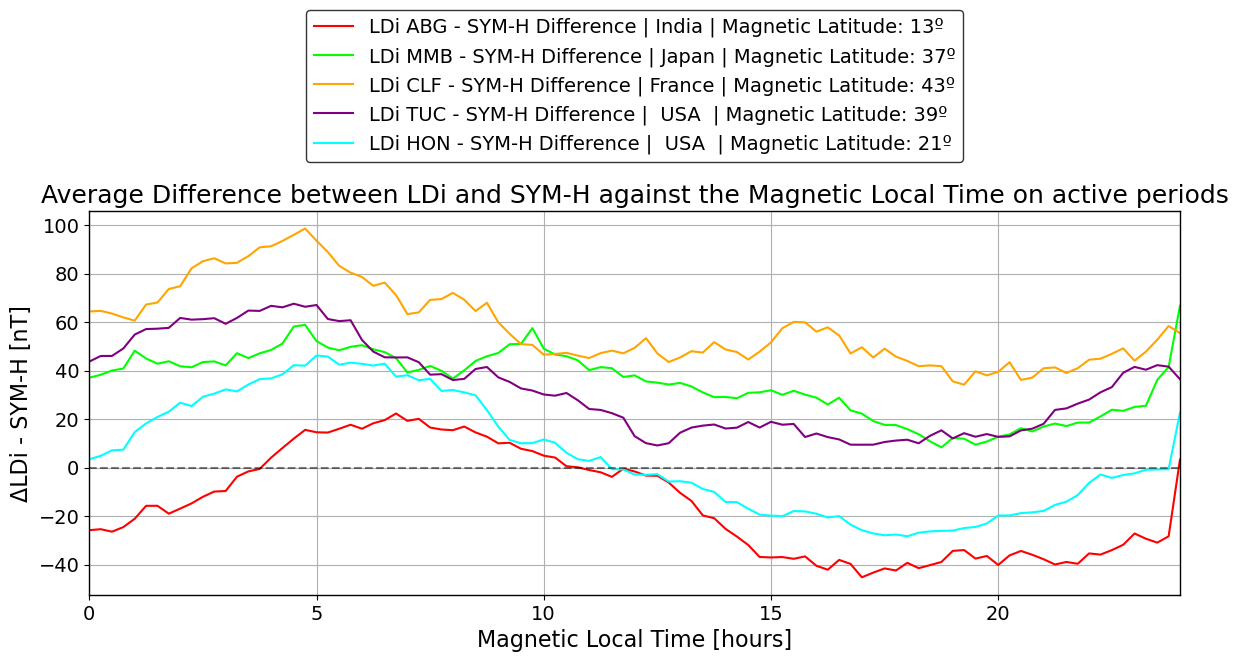

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for i, station in enumerate(constants.TRAIN_STATIONS):

    all_storms_station = all_storms_active[
        [
            f"LDi_{station}",
            f"MLT_{station}",
            "SYM_H",
            f"LDi_{station}_SYM_H_diff",
            f"LDi_{station}_SYM_H_diff_abs",
            f"Latitude_{station}",
        ]
    ].dropna()

    all_storms_station[f"MLT_quarter_hour_{station}"] = (
        all_storms_station[f"MLT_{station}"] // 0.25
    ) * 0.25

    grouped = (
        all_storms_station.groupby(f"MLT_quarter_hour_{station}")
        .agg(
            {
                "SYM_H": "mean",
                f"LDi_{station}": "mean",
                f"LDi_{station}_SYM_H_diff": "mean",
                f"Latitude_{station}": "mean",
            }
        )
        .reset_index()
    )

    ax.plot(
        grouped[f"MLT_quarter_hour_{station}"],
        grouped[f"LDi_{station}_SYM_H_diff"],
        label=f"LDi {station} - SYM-H Difference | {' USA ' if constants.COUNTRY_STATIONS[station] == 'USA' else constants.COUNTRY_STATIONS[station]} | Magnetic Latitude: {grouped[f'Latitude_{station}'].iloc[0]:.0f}º",
        color=constants.COLOR_STATIONS[station],
    )

ax.set_xlabel("Magnetic Local Time [hours]", fontsize=16)
ax.set_ylabel(u"ΔLDi - SYM-H [nT]", fontsize=16)
ax.set_title(
    "Average Difference between LDi and SYM-H against the Magnetic Local Time on active periods",
    fontsize=18,
)

ax.set_xlim((0, 24))
ax.axhline(0, color="black", linestyle="--", alpha=0.5)

ax.tick_params(axis="both", labelsize=14)

# ax.tick_params(axis="x", which="major", labelsize=14, width=2, length=10, direction="inout")
# ax.tick_params(axis="y", which="major", labelsize=14, width=2, length=10, direction="inout")
# Ensure that the grid is enabled and properly configured

leg = ax.legend(
    bbox_to_anchor=(0.5, 1.55),
    loc="upper center",
    ncol=1,
    fancybox=True,
    prop={"size": 14},
    edgecolor="black",
    facecolor="none",
)

ax.grid(True)

plt.setp(ax.spines.values(), lw=1, color="black", alpha=1)

plt.tight_layout()

plt.savefig("./figs/avg-diff-ldi-sym-active.png", dpi = 300, transparent=True, bbox_inches='tight')
# plt.legend();
plt.show()

In [9]:
# Rough way to eliminate very incorrect data in the whole timeline for the inactive data
for station in constants.TRAIN_STATIONS:
    all_inactive[f'{station}_Diff'] = all_inactive[f'LDi_{station}'] - all_inactive[f'SYM_H']
    all_inactive.loc[all_inactive[f'{station}_Diff'].abs() > 200, f'LDi_{station}'] = np.nan

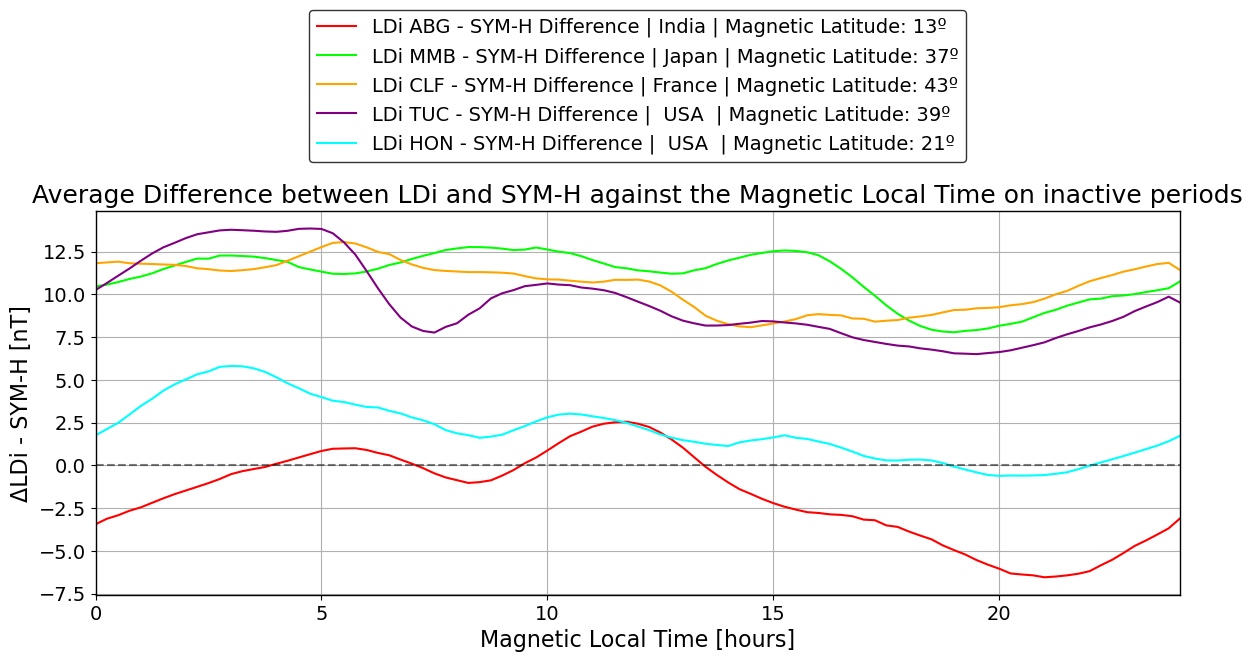

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for i, station in enumerate(constants.TRAIN_STATIONS):

    all_storms_station = all_inactive[
        [
            f"LDi_{station}",
            f"MLT_{station}",
            "SYM_H",
            f"LDi_{station}_SYM_H_diff",
            f"LDi_{station}_SYM_H_diff_abs",
            f"Latitude_{station}",
        ]
    ].dropna()

    all_storms_station[f"MLT_quarter_hour_{station}"] = (
        all_storms_station[f"MLT_{station}"] // 0.25
    ) * 0.25

    grouped = (
        all_storms_station.groupby(f"MLT_quarter_hour_{station}")
        .agg(
            {
                "SYM_H": "mean",
                f"LDi_{station}": "mean",
                f"LDi_{station}_SYM_H_diff": "mean",
                f"Latitude_{station}": "mean",
            }
        )
        .reset_index()
    )

    ax.plot(
        grouped[f"MLT_quarter_hour_{station}"],
        grouped[f"LDi_{station}_SYM_H_diff"],
        label=f"LDi {station} - SYM-H Difference | {' USA ' if constants.COUNTRY_STATIONS[station] == 'USA' else constants.COUNTRY_STATIONS[station]} | Magnetic Latitude: {grouped[f'Latitude_{station}'].iloc[0]:.0f}º",
        color=constants.COLOR_STATIONS[station],
    )

ax.set_xlabel("Magnetic Local Time [hours]", fontsize=16)
ax.set_ylabel(u"ΔLDi - SYM-H [nT]", fontsize=16)
ax.set_title(
    "Average Difference between LDi and SYM-H against the Magnetic Local Time on inactive periods",
    fontsize=18,
)
plt.setp(ax.spines.values(), lw=2, color="black", alpha=1)

ax.set_xlim((0, 24))
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.tick_params(axis='both', labelsize=14)

#ax.tick_params(axis="x", which="major", labelsize=14, width=2, length=10)
#ax.tick_params(axis="y", which="major", labelsize=14, width=2, length=10)
ax.grid(True)
# Ensure that the grid is enabled and properly configured

leg = ax.legend(
    bbox_to_anchor=(0.5, 1.55),
    loc="upper center",
    ncol=1,
    fancybox=True,
    prop={"size": 14},
    edgecolor="black",
    facecolor="none",
)

plt.setp(ax.spines.values(), lw=1, color="black", alpha=1)

plt.tight_layout()

plt.savefig("./figs/avg-diff-ldi-sym-inactive.png", dpi = 300, transparent=True, bbox_inches='tight')
# plt.legend();
plt.show()

Plots for station ABG


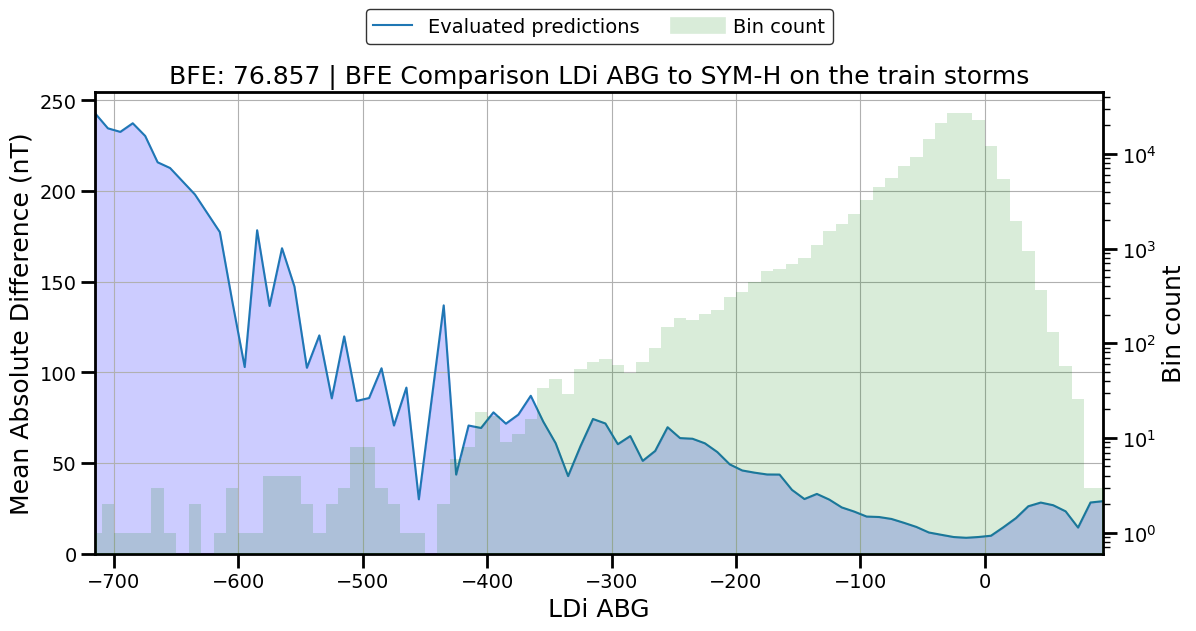

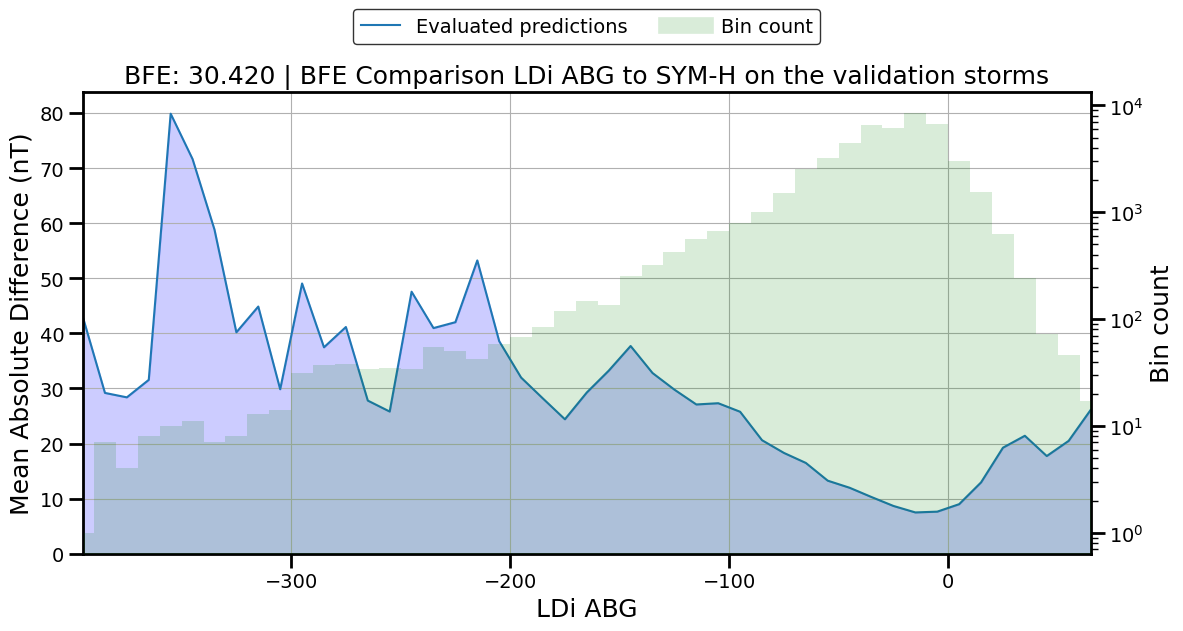

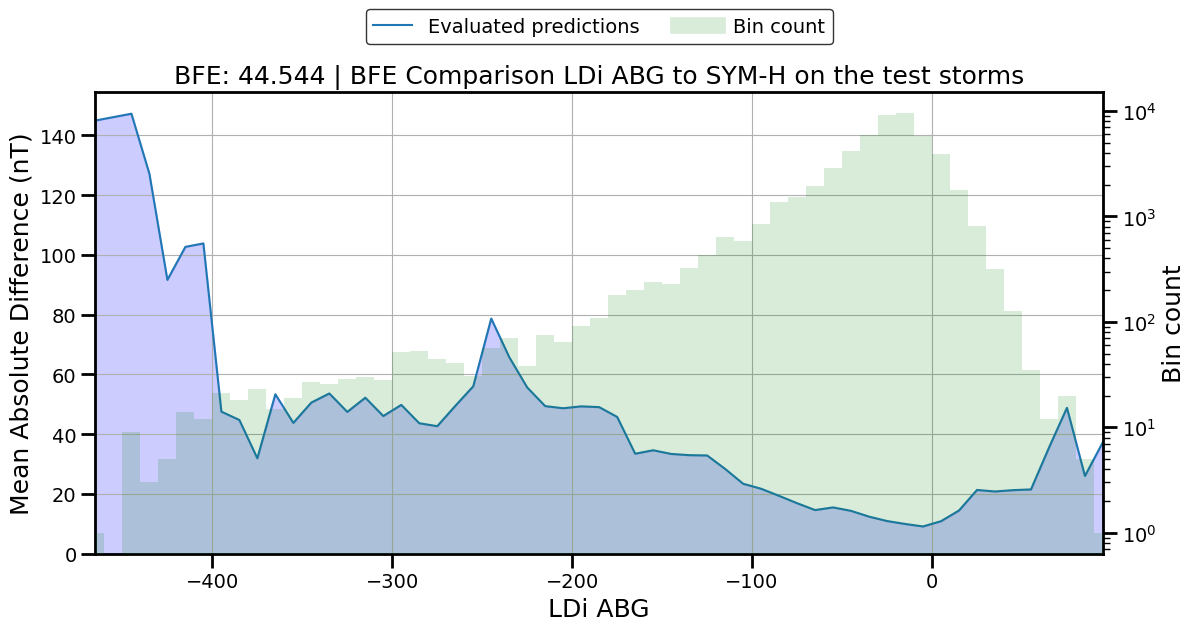

Plots for station MMB


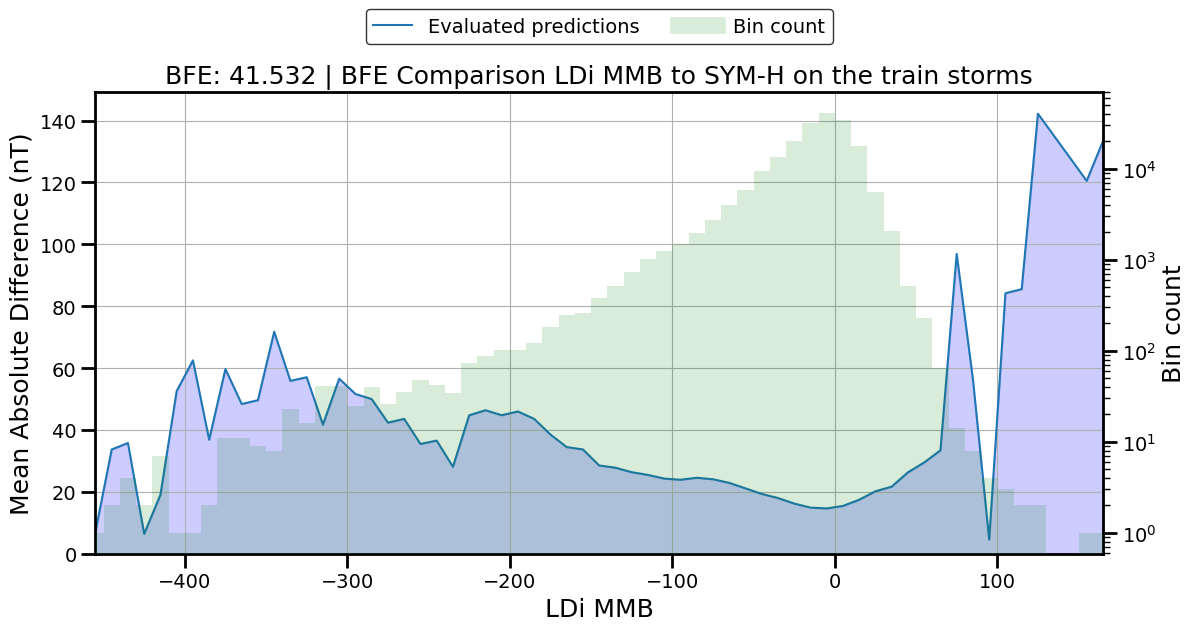

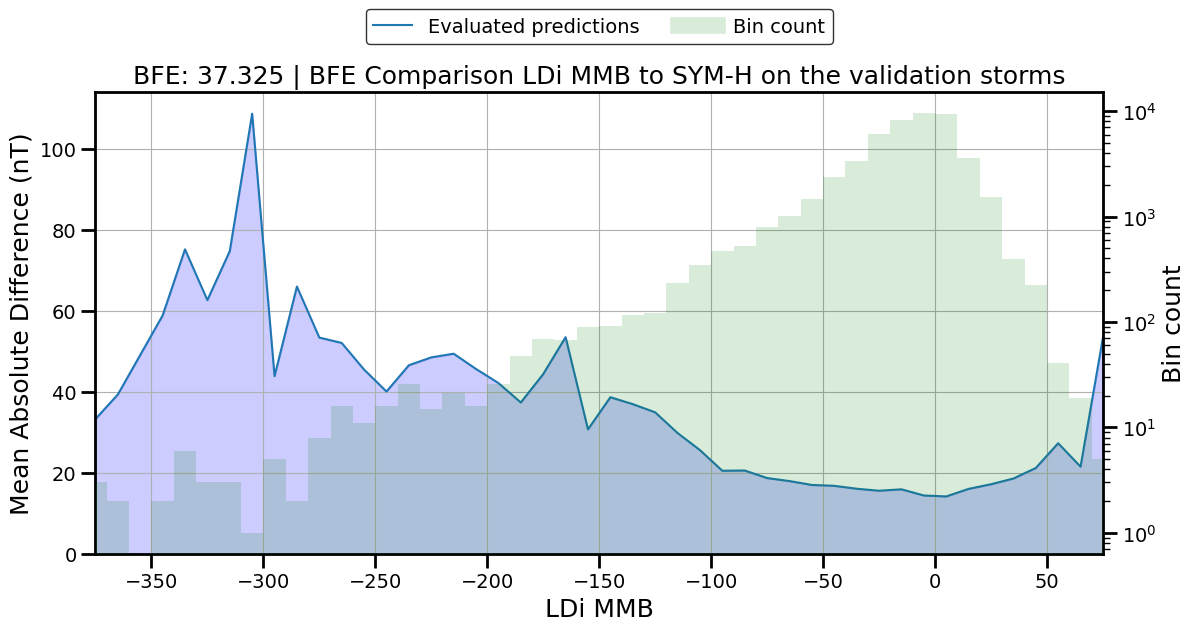

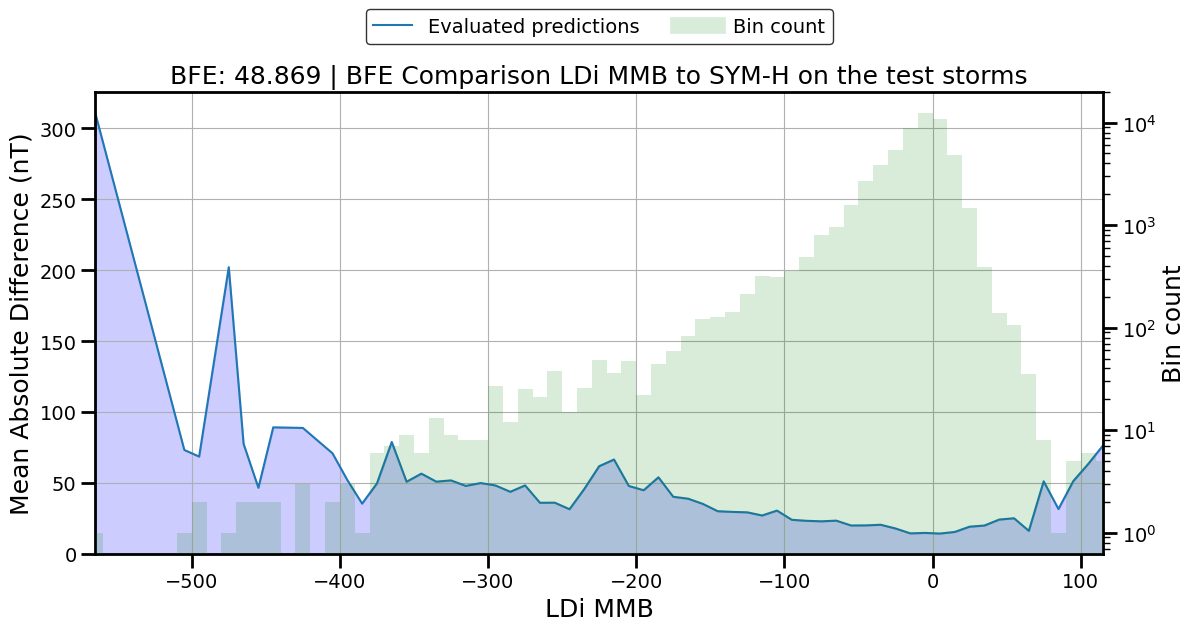

Plots for station CLF


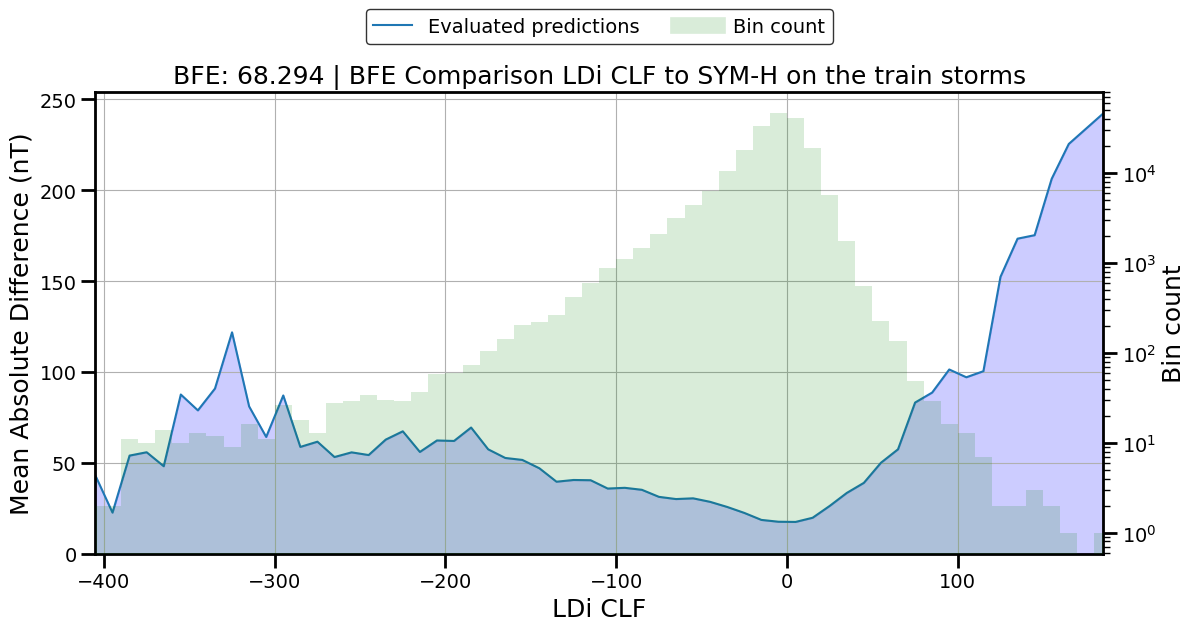

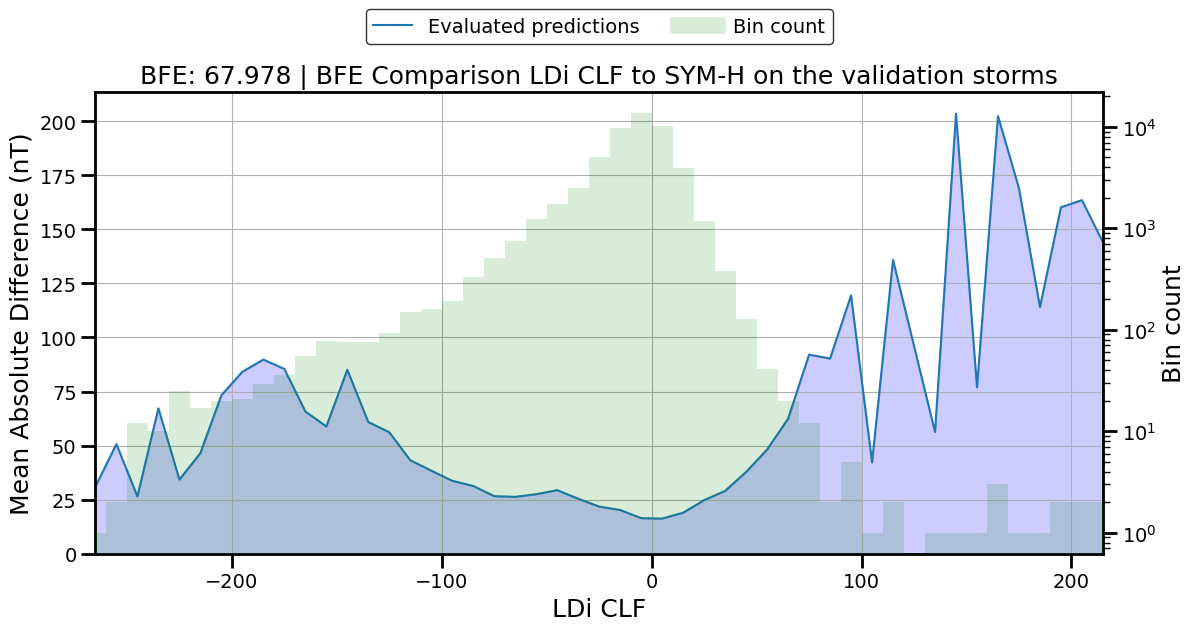

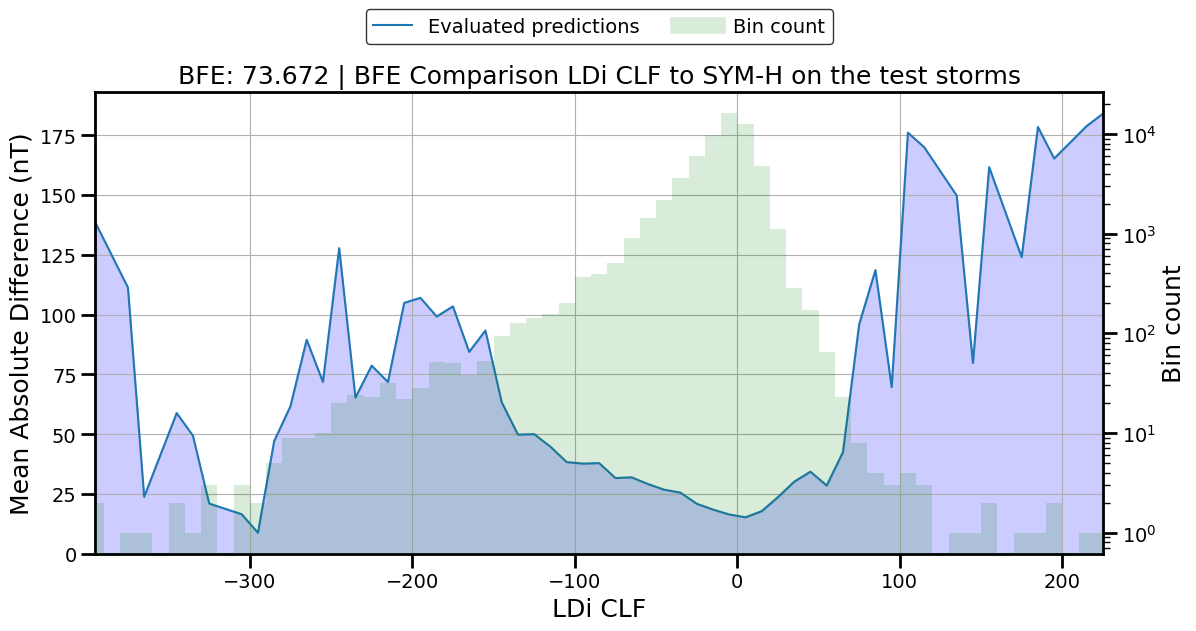

Plots for station TUC


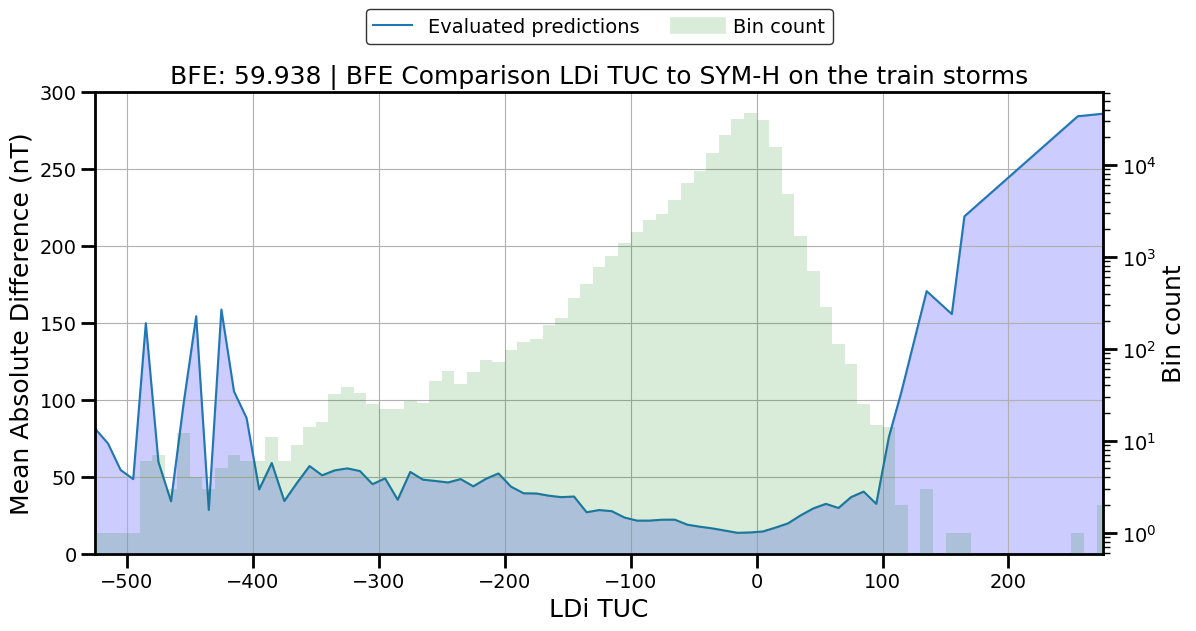

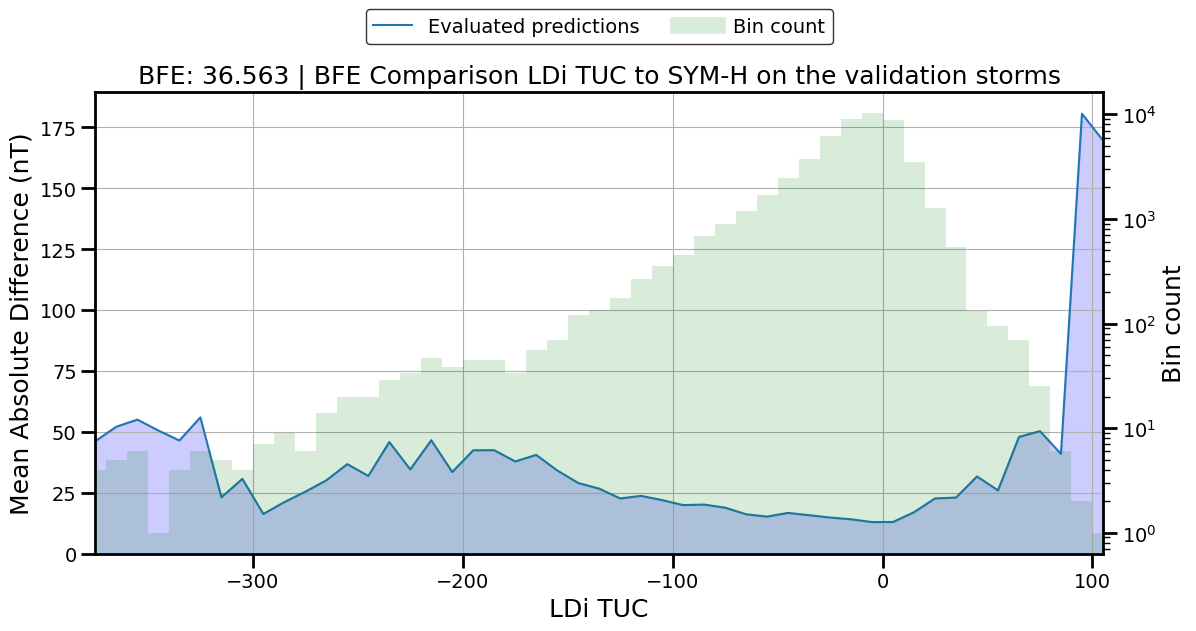

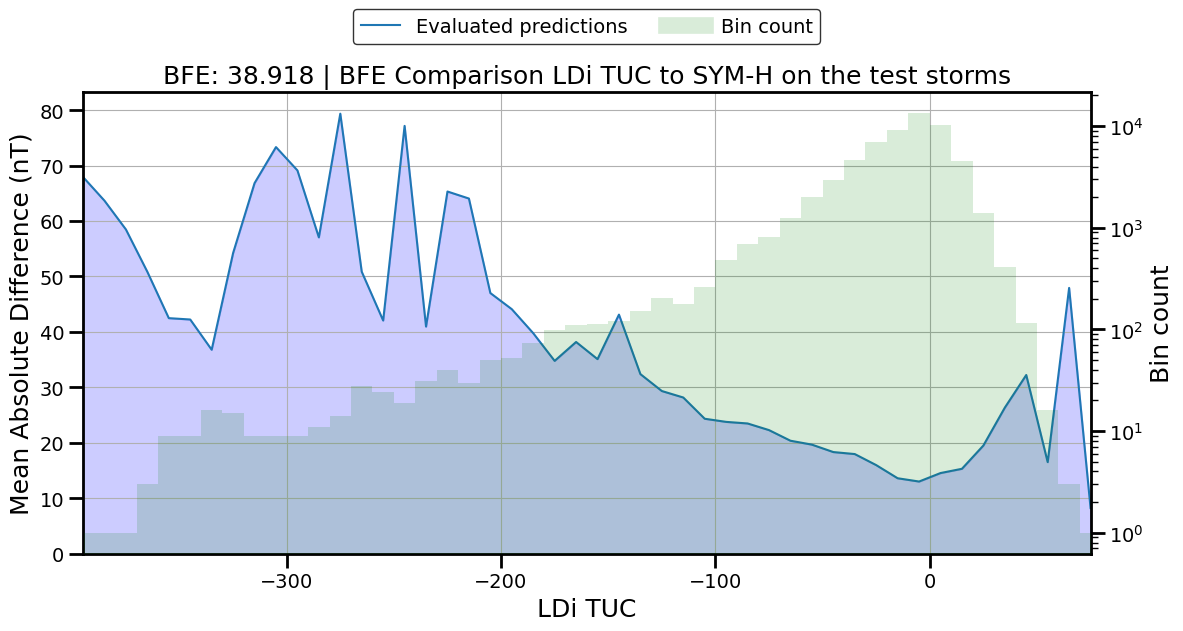

Plots for station HON


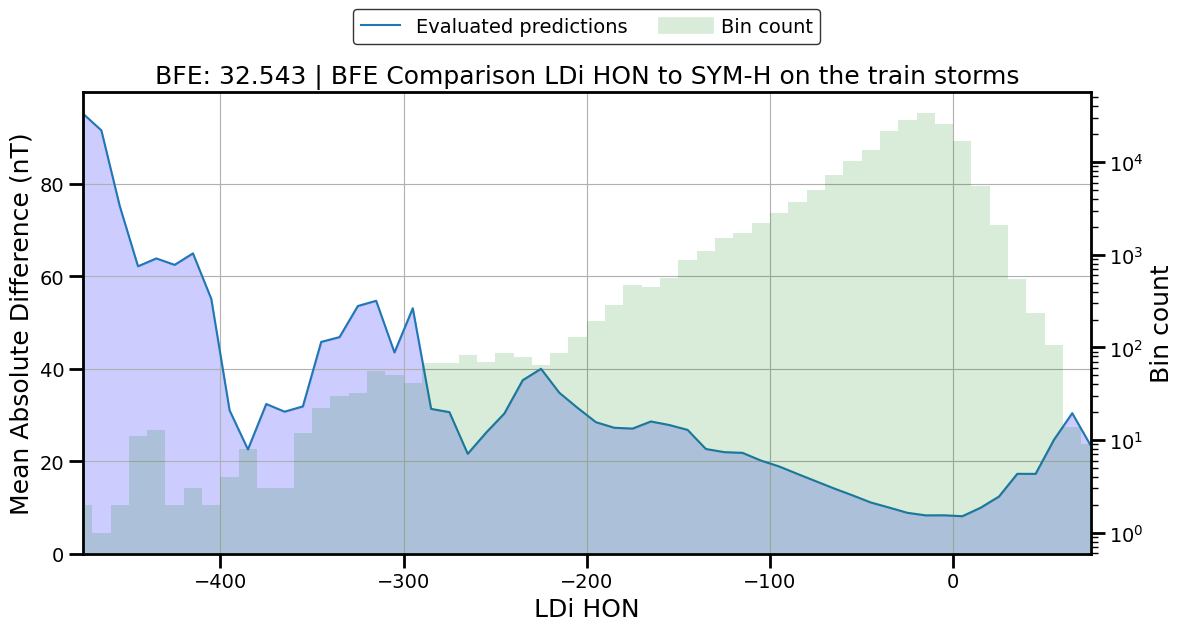

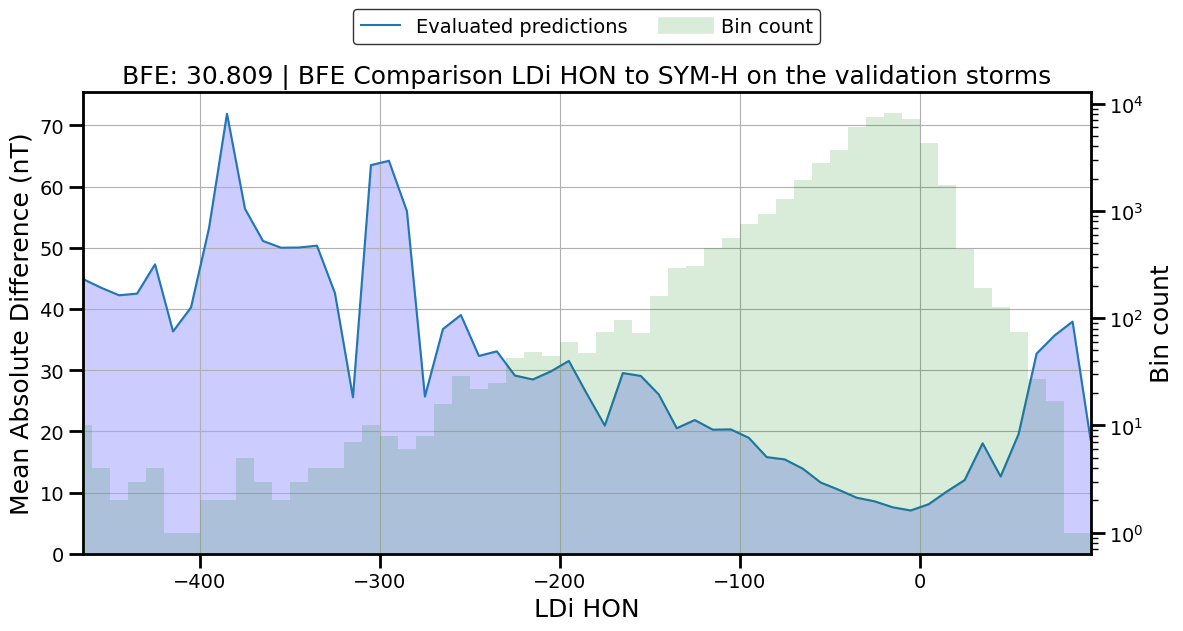

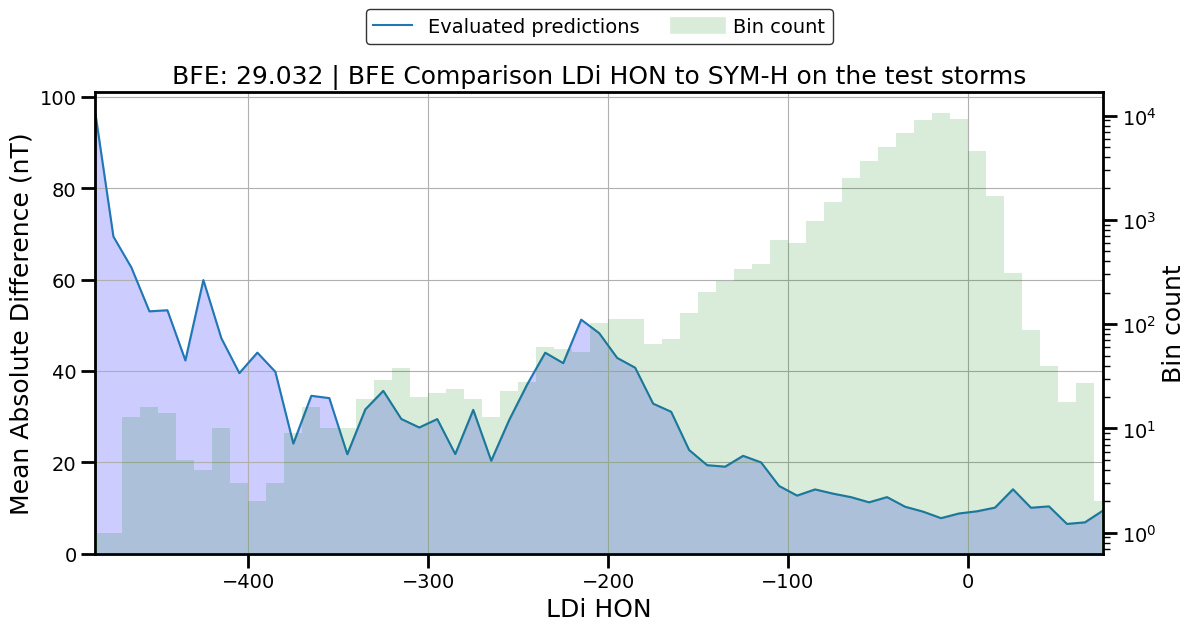

Plot for test storms in SFS


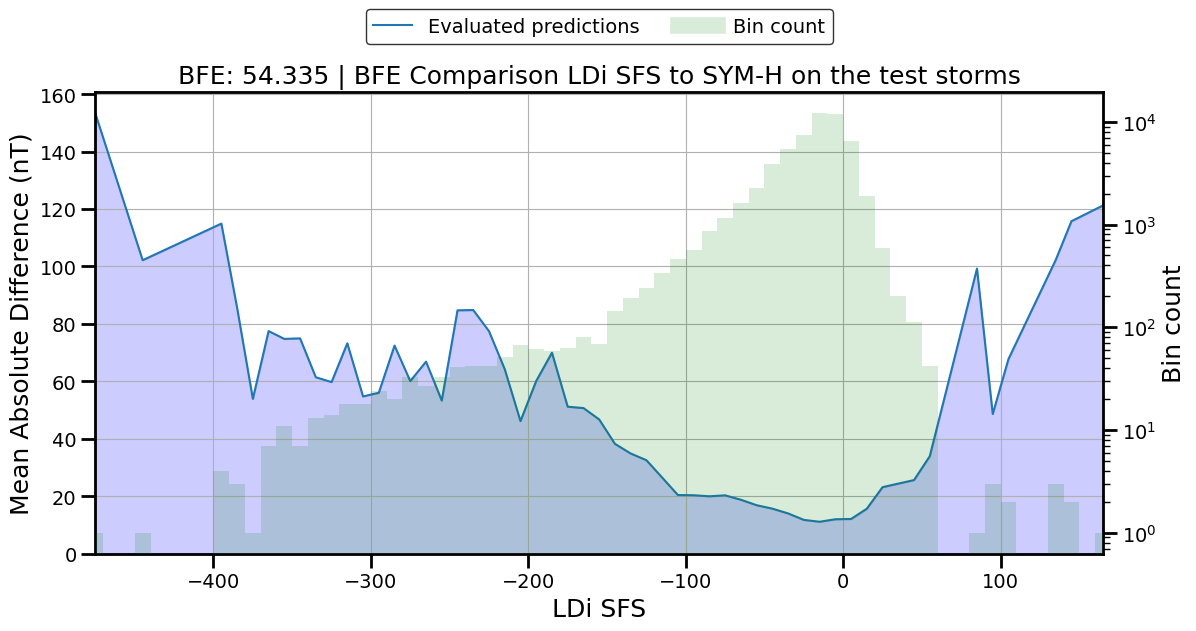

In [11]:
trains = pd.concat(train_storms)
vals = pd.concat(val_storms)
tests = pd.concat(test_storms)
                   
for station in constants.TRAIN_STATIONS:
    print(f'Plots for station {station}')
    metrics.plot_evaluation_bfe(trains[[f'LDi_{station}', 'SYM_H']], title = f'BFE Comparison LDi {station} to SYM-H on the train storms', xlabel_title=f'LDi {station}')
    plt.show();
    
    metrics.plot_evaluation_bfe(vals[[f'LDi_{station}', 'SYM_H']], title = f'BFE Comparison LDi {station} to SYM-H on the validation storms', xlabel_title=f'LDi {station}')
    plt.show();
    
    metrics.plot_evaluation_bfe(tests[[f'LDi_{station}', 'SYM_H']], title = f'BFE Comparison LDi {station} to SYM-H on the test storms', xlabel_title=f'LDi {station}')
    plt.savefig(f'./figs/bfe-ldi-{station}-symh.png', transparent=True)
    plt.show();
    
print(f'Plot for test storms in SFS')
metrics.plot_evaluation_bfe(tests[[f'LDi_SFS', 'SYM_H']], title = f'BFE Comparison LDi SFS to SYM-H on the test storms', xlabel_title=f'LDi SFS')
plt.savefig(f'./figs/bfe-ldi-SFS-symh.png', transparent=True)
plt.show();

Plots for station ABG


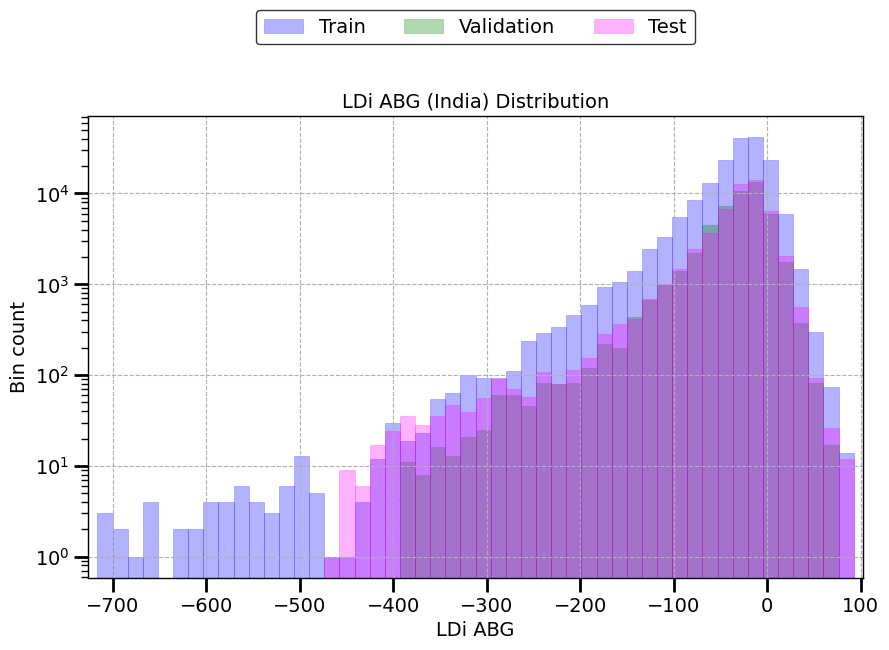

Plots for station MMB


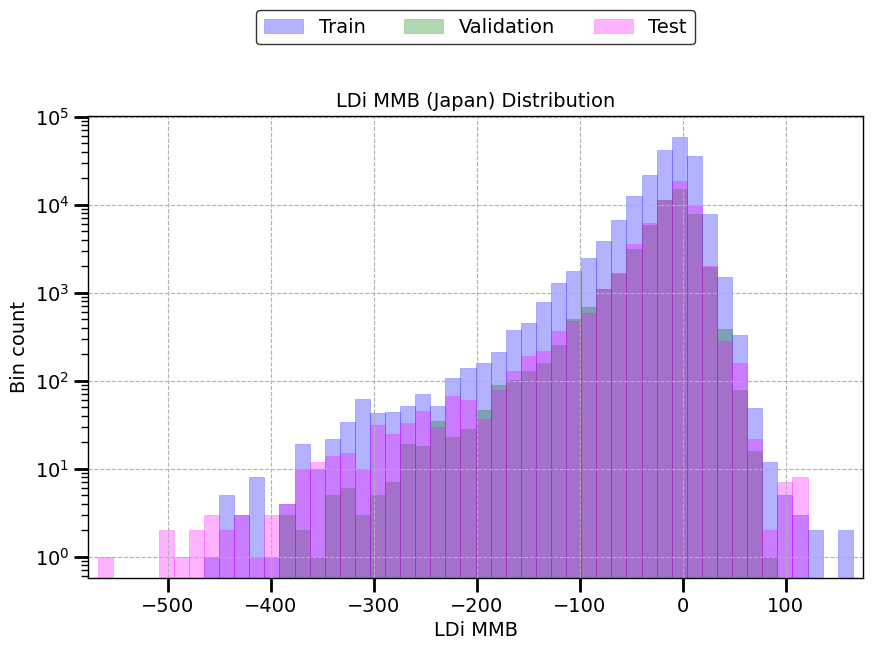

Plots for station CLF


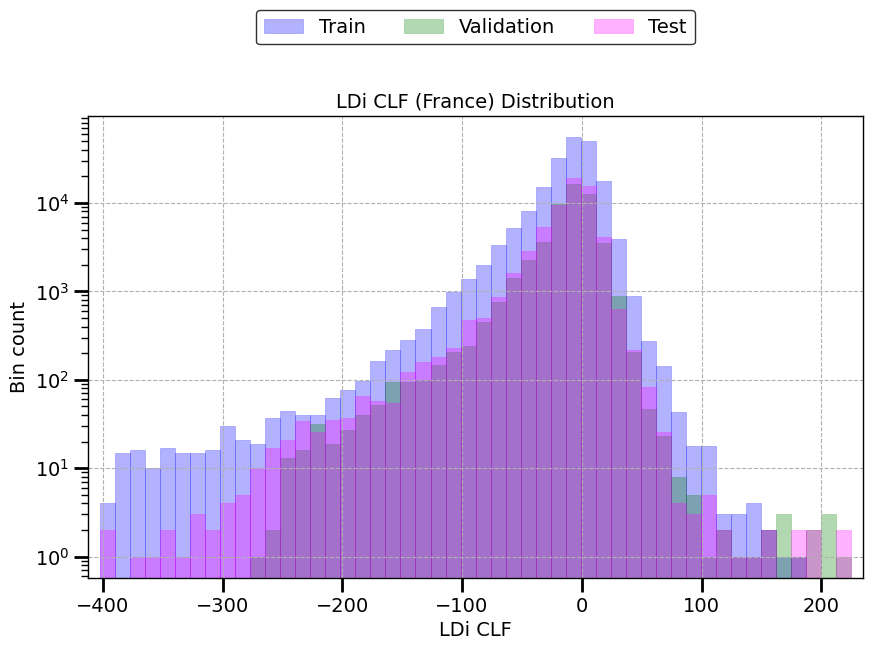

Plots for station TUC


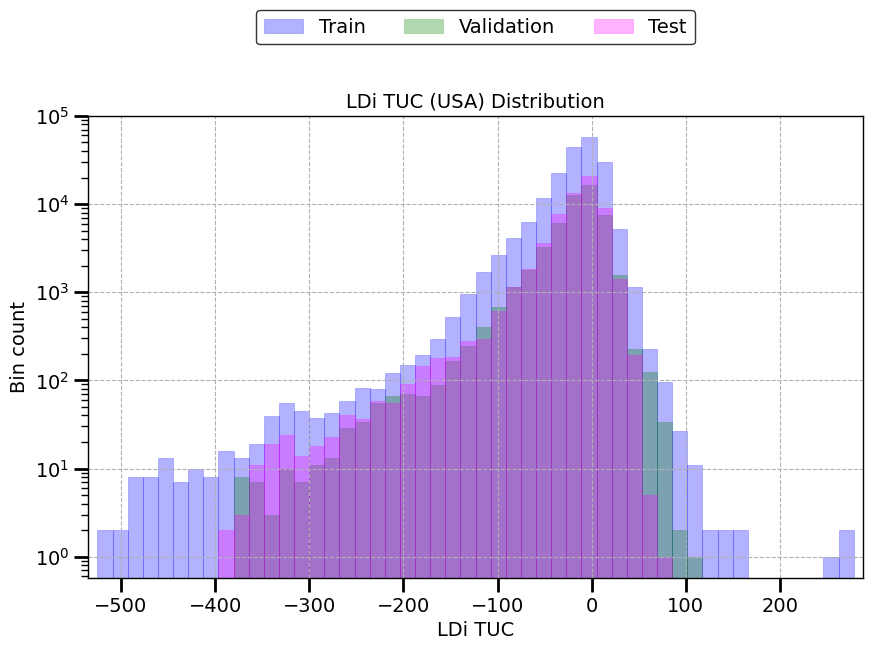

Plots for station HON


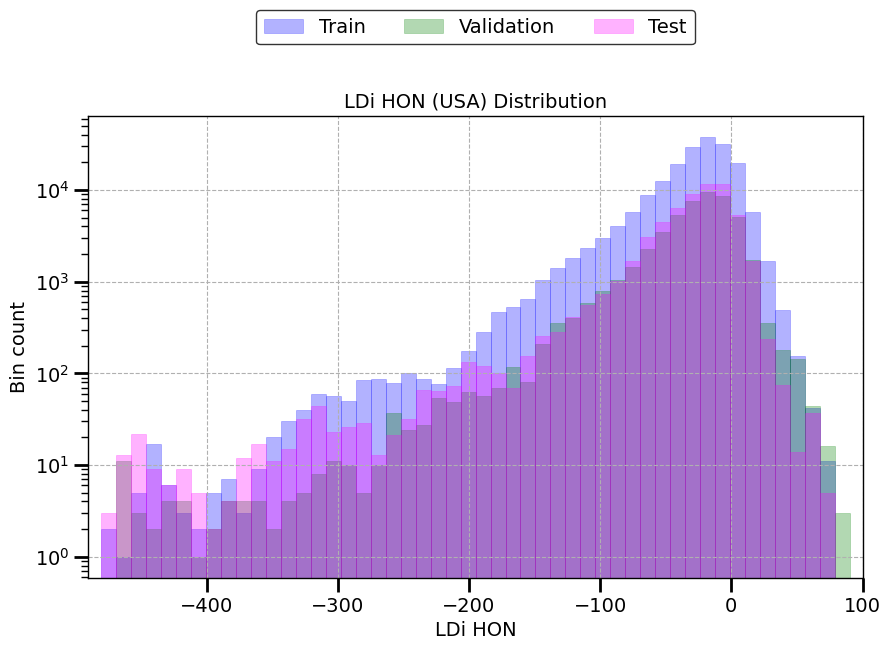

In [12]:
global_min = np.inf
global_max = -np.inf

for station_index, station in enumerate(constants.TRAIN_STATIONS):
    print(f"Plots for station {station}")
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    station_min = min(
            trains[f"LDi_{station}"].min(),
            vals[f"LDi_{station}"].min(),
            tests[f"LDi_{station}"].min(),
        )
    station_max = max(
            trains[f"LDi_{station}"].max(),
            vals[f"LDi_{station}"].max(),
            tests[f"LDi_{station}"].max(),
        )
    bins = np.linspace(station_min, station_max, 51)
    ax.hist(
        trains[f"LDi_{station}"].dropna(),
        density=False,
        color="blue",
        alpha=0.3,
        label=f"Train",
        bins=bins,
        edgecolor="blue",
        linewidth=0.5,
    )
    ax.hist(
        vals[f"LDi_{station}"].dropna(),
        density=False,
        color="green",
        alpha=0.3,
        label=f"Validation",
        bins=bins,
        edgecolor="green",
        linewidth=0.5,
    )
    ax.hist(
        tests[f"LDi_{station}"].dropna(),
        density=False,
        color="magenta",
        alpha=0.3,
        label=f"Test",
        bins=bins,
        edgecolor="magenta",
        linewidth=0.5,
    )
    ax.set_yscale("log")
    
    ax.grid(linestyle="--")
    ax.legend()
    ax.set_ylabel("Bin count", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=14, width=2, length=10)
    ax.tick_params(axis="both", which="minor", width=1, length=5)
    ax.set_xlabel(f"LDi {station}", fontsize=14)
    ax.set_xlim(station_min - 10, station_max + 10)
    
    leg = ax.legend(
        ncol=3,
        fancybox=True,
        prop={"size": 14},
        bbox_to_anchor=(0.5, 1.25),
        loc="upper center",
        facecolor="none",
    )
    
    ax.set_title(
        f"LDi {station} ({constants.COUNTRY_STATIONS[station]}) Distribution", fontsize=14
    )
    
    global_min = min(global_min, station_min)
    global_max = max(global_max, station_max)    
    
    leg.get_frame().set_edgecolor("black")
    plt.setp(ax.spines.values(), lw=1, color="black", alpha=1)
    plt.savefig(f"./figs/ldi-distribution-{station}.png", transparent=True, bbox_inches='tight')
    plt.show()

Plots for station ABG


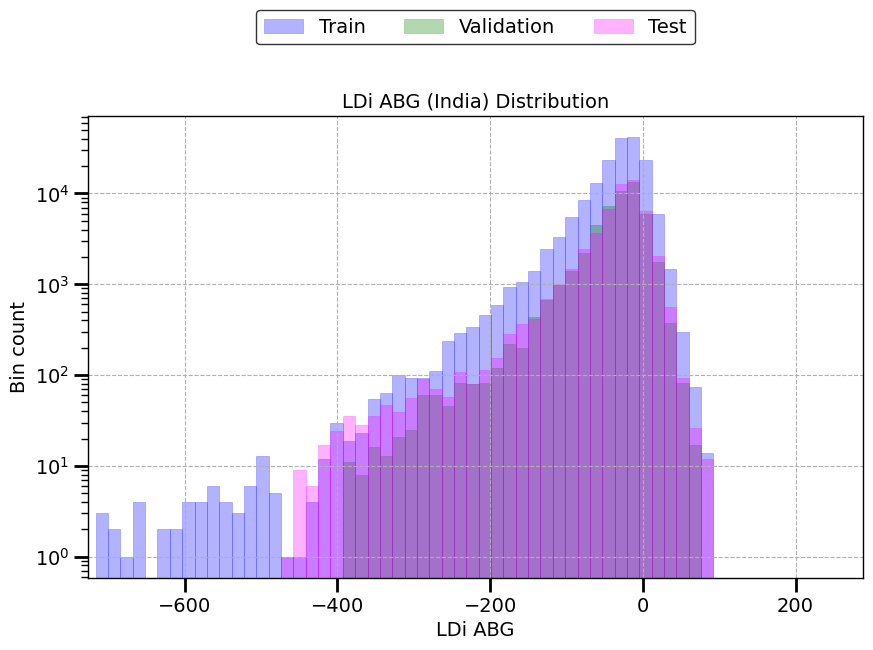

Plots for station MMB


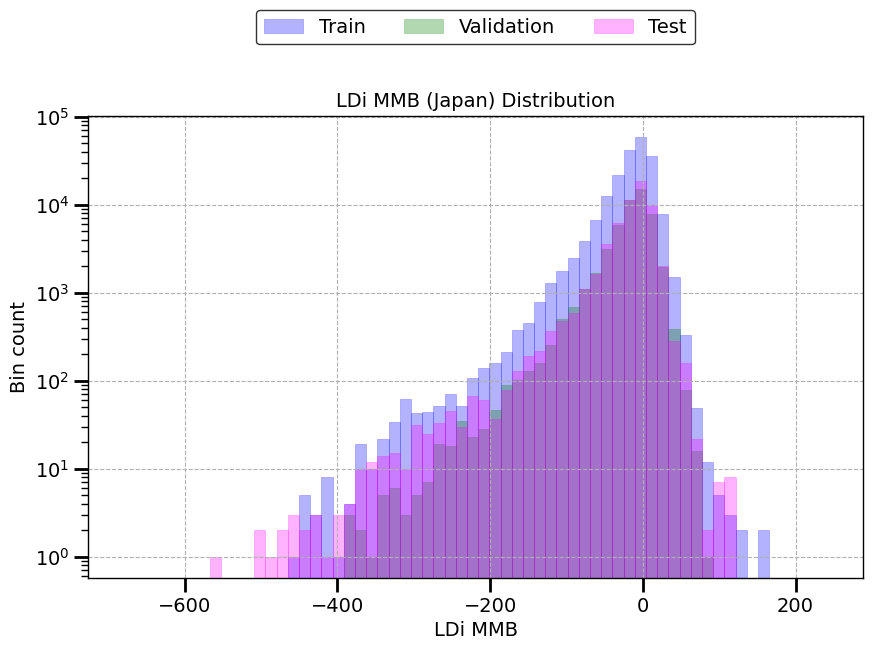

Plots for station CLF


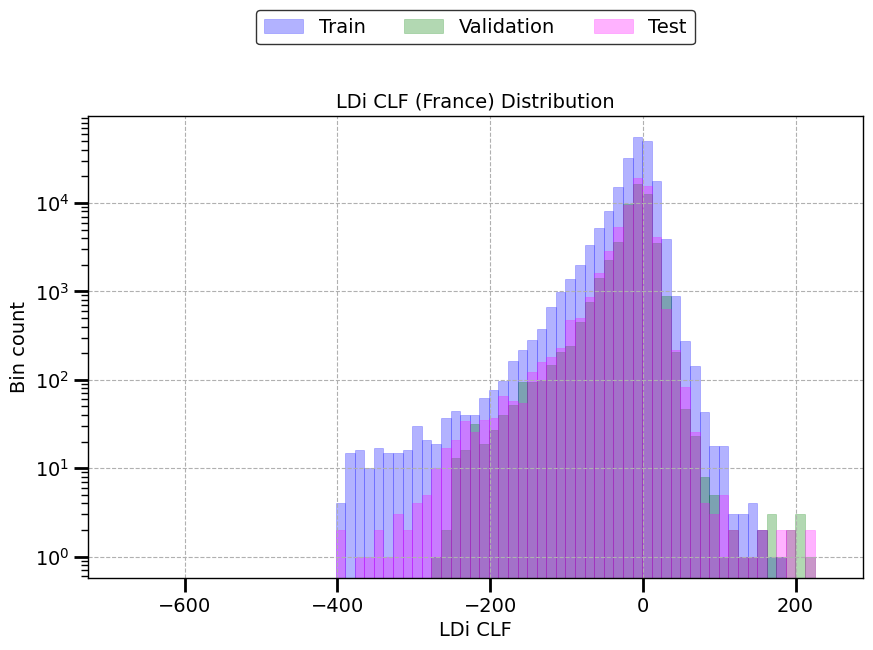

Plots for station TUC


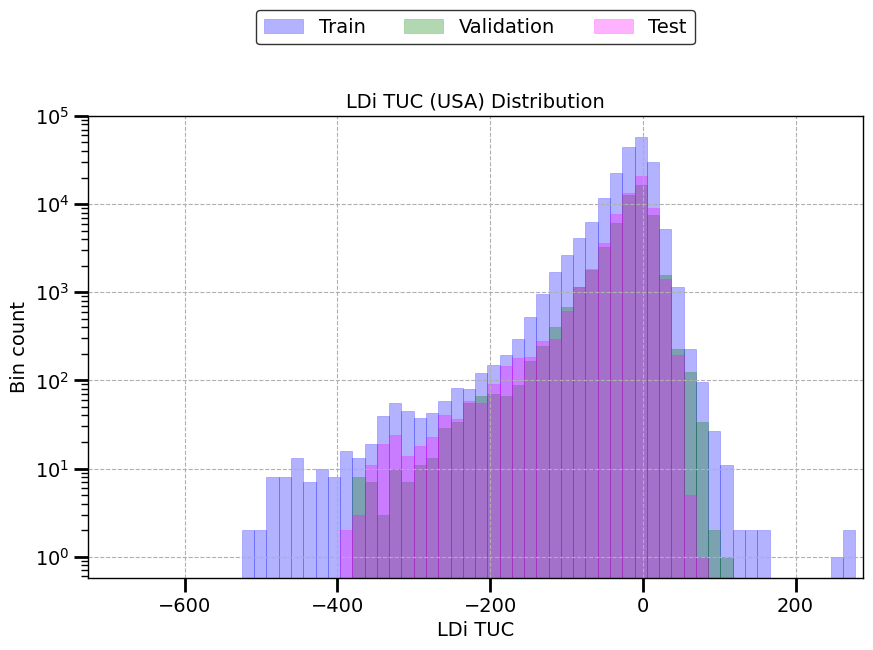

Plots for station HON


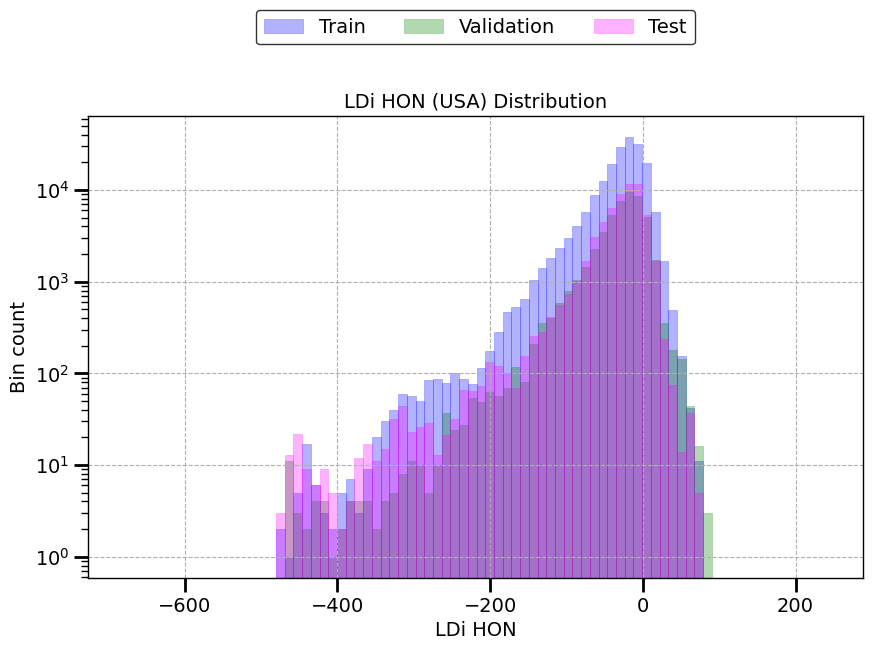

In [13]:
for station_index, station in enumerate(constants.TRAIN_STATIONS):
    print(f"Plots for station {station}")
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    station_min = min(
            trains[f"LDi_{station}"].min(),
            vals[f"LDi_{station}"].min(),
            tests[f"LDi_{station}"].min(),
        )
    station_max = max(
            trains[f"LDi_{station}"].max(),
            vals[f"LDi_{station}"].max(),
            tests[f"LDi_{station}"].max(),
        )
    bins = np.linspace(station_min, station_max, 51)
    ax.hist(
        trains[f"LDi_{station}"].dropna(),
        density=False,
        color="blue",
        alpha=0.3,
        label=f"Train",
        bins=bins,
        edgecolor="blue",
        linewidth=0.5,
    )
    ax.hist(
        vals[f"LDi_{station}"].dropna(),
        density=False,
        color="green",
        alpha=0.3,
        label=f"Validation",
        bins=bins,
        edgecolor="green",
        linewidth=0.5,
    )
    ax.hist(
        tests[f"LDi_{station}"].dropna(),
        density=False,
        color="magenta",
        alpha=0.3,
        label=f"Test",
        bins=bins,
        edgecolor="magenta",
        linewidth=0.5,
    )
    ax.set_yscale("log")
    
    ax.grid(linestyle="--")
    ax.legend()
    ax.set_ylabel("Bin count", fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=14, width=2, length=10)
    ax.tick_params(axis="both", which="minor", width=1, length=5)
    ax.set_xlabel(f"LDi {station}", fontsize=14)
    ax.set_xlim(global_min - 10, global_max + 10)
    
    leg = ax.legend(
        ncol=3,
        fancybox=True,
        prop={"size": 14},
        bbox_to_anchor=(0.5, 1.25),
        loc="upper center",
        facecolor="none",
    )
    
    ax.set_title(
        f"LDi {station} ({constants.COUNTRY_STATIONS[station]}) Distribution", fontsize=14
    )
    
    
    leg.get_frame().set_edgecolor("black")
    plt.setp(ax.spines.values(), lw=1, color="black", alpha=1)
    plt.savefig(f"./figs/ldi-distribution-{station}-xlim.png", transparent=True, bbox_inches='tight')
    plt.show()